In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

# Load
df = pd.read_csv('Employee_Attrition.csv')
df.head()

c:\Users\vinay\OneDrive\Desktop\KMV\RUAS\Projects\Employee_Attrition\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Text(0.5, 1.0, 'Correlation Analysis')

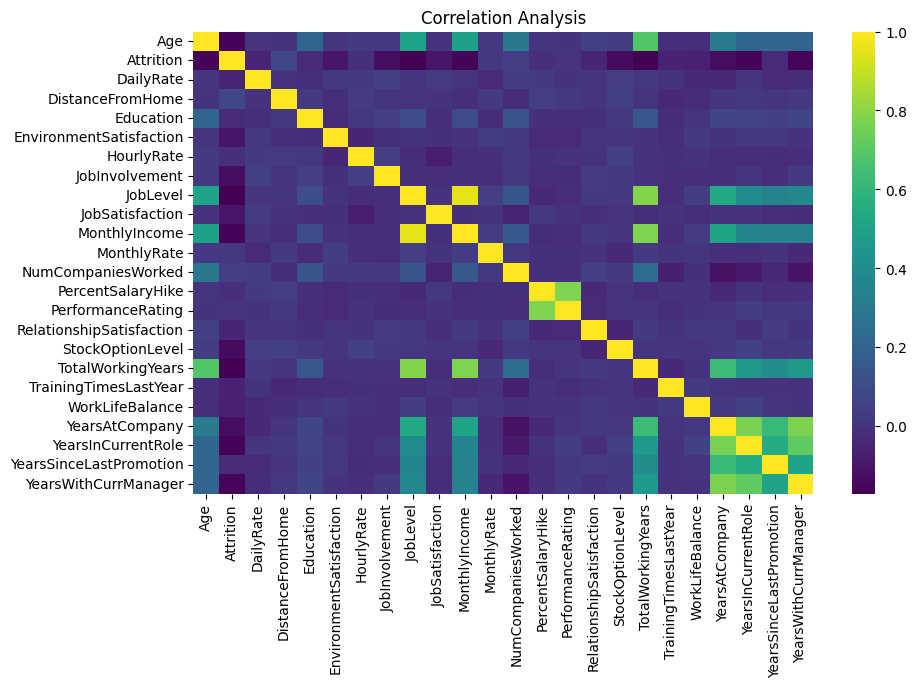

In [2]:
# Drop columns with zero variance (they don't help the model)
df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1, inplace=True)

# Encode Attrition (Target)
le = LabelEncoder()
df['Attrition'] = le.fit_transform(df['Attrition'])

# Convert categories to numbers (One-Hot Encoding)
df_final = pd.get_dummies(df, drop_first=True)

# Visualize Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='viridis')
plt.title("Correlation Analysis")

In [3]:
# Split Features and Target
X = df_final.drop('Attrition', axis=1)
y = df_final['Attrition']

# Address Imbalance (SMOTE)
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Scale & Split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Selection: Random Forest
# Justification: High performance on tabular data and natively supported by SHAP TreeExplainer.
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

--- Generating Global Explanation (SHAP Summary Plot) ---


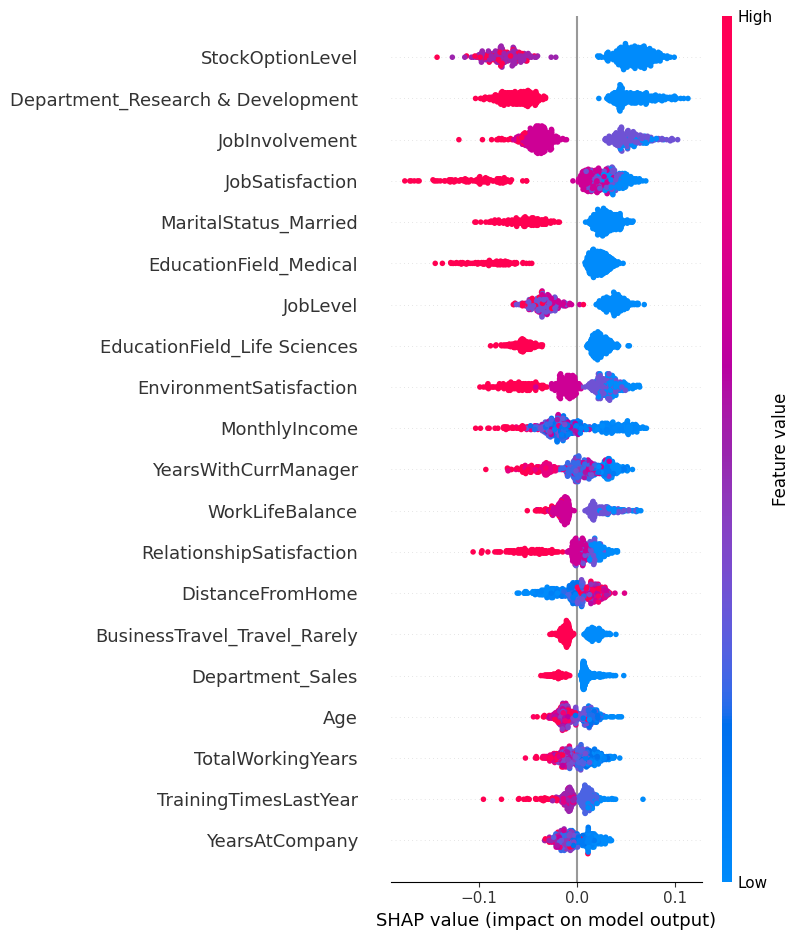


--- Local Explanation for Employee at Index 0 ---


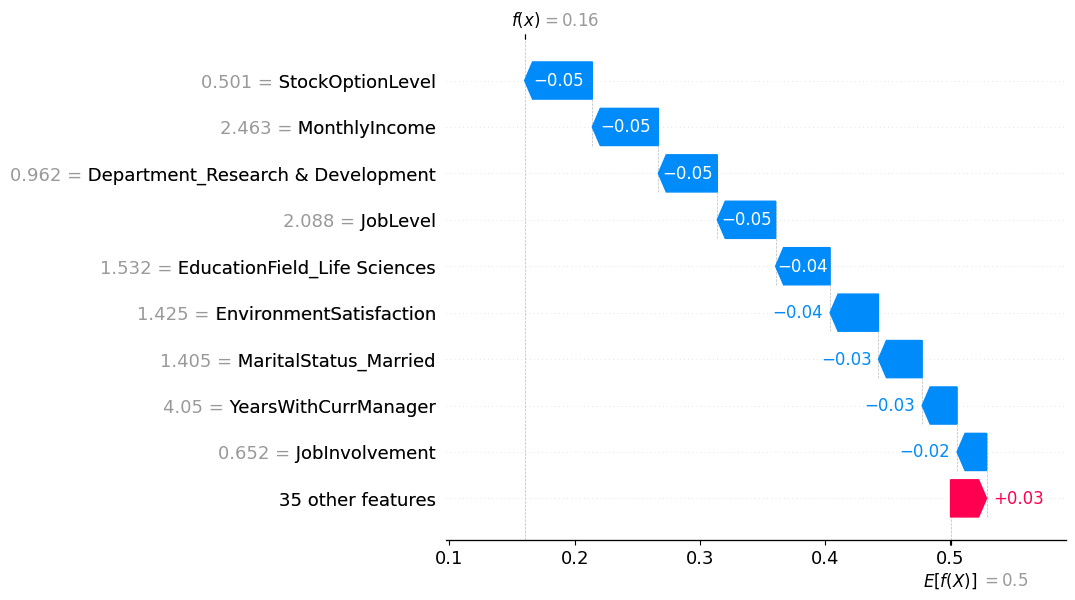

In [4]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Setup SHAP Explainer
# We use the already trained 'model' from the previous cell
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

# --- SHAP Shape Fix ---
# Ensures we are explaining 'Attrition = Yes' (Class 1)
if isinstance(shap_values, list):
    final_shap_values = shap_values[1]
    base_value = explainer.expected_value[1]
elif len(shap_values.shape) == 3:
    final_shap_values = shap_values[:, :, 1]
    base_value = explainer.expected_value[1]
else:
    final_shap_values = shap_values
    base_value = explainer.expected_value

# Create DataFrame so the plots show feature names instead of column numbers
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# 2. Global Explanation (The "Big Picture")
print("--- Generating Global Explanation (SHAP Summary Plot) ---")
shap.summary_plot(final_shap_values, X_test_scaled_df)

# 3. Local Explanation (Analysis of a Single Employee)
employee_idx = 0 
print(f"\n--- Local Explanation for Employee at Index {employee_idx} ---")

# Create the Explanation object for the waterfall plot
exp = shap.Explanation(
    values=final_shap_values[employee_idx], 
    base_values=base_value, 
    data=X_test_scaled_df.iloc[employee_idx], 
    feature_names=X.columns
)

# Render the Waterfall plot
shap.plots.waterfall(exp)

In [5]:
from sklearn.linear_model import LogisticRegression

# Initialize and Train
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predict and Evaluate
lr_pred = lr_model.predict(X_test_scaled)
print("--- Logistic Regression Performance ---")
print(classification_report(y_test, lr_pred))

--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       250
           1       0.91      0.87      0.89       244

    accuracy                           0.90       494
   macro avg       0.90      0.90      0.90       494
weighted avg       0.90      0.90      0.90       494



In [6]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and Train
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Predict and Evaluate
dt_pred = dt_model.predict(X_test_scaled)
print("--- Decision Tree Performance ---")
print(classification_report(y_test, dt_pred))

--- Decision Tree Performance ---
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       250
           1       0.84      0.86      0.85       244

    accuracy                           0.85       494
   macro avg       0.85      0.85      0.85       494
weighted avg       0.85      0.85      0.85       494



In [7]:
# Initialize and Train (Using the code we wrote earlier)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict and Evaluate
rf_pred = rf_model.predict(X_test_scaled)
print("--- Random Forest Performance ---")
print(classification_report(y_test, rf_pred))

--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       250
           1       0.94      0.89      0.92       244

    accuracy                           0.92       494
   macro avg       0.92      0.92      0.92       494
weighted avg       0.92      0.92      0.92       494



In [8]:
from sklearn.metrics import accuracy_score, f1_score

model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
predictions = [lr_pred, dt_pred, rf_pred]

summary = []
for name, pred in zip(model_names, predictions):
    summary.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred)
    })

comparison_df = pd.DataFrame(summary)
print(comparison_df)

                 Model  Accuracy  F1-Score
0  Logistic Regression  0.896761  0.893082
1        Decision Tree  0.846154  0.846154
2        Random Forest  0.919028  0.915612


In [ ]:
import shap
import pandas as pd
import numpy as np

# 1. Re-initialize Explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

# 2. Extract Class 1 (Attrition = Yes) safely
# Random Forest SHAP values often come as [samples, features, classes] 
# or a list of [samples, features]
if isinstance(shap_values, list):
    # If it's a list, index 1 is usually 'Yes'
    final_shap_values = shap_values[1]
elif len(shap_values.shape) == 3:
    # If it's a 3D array, take the last slice (Class 1)
    final_shap_values = shap_values[:, :, 1]
else:
    final_shap_values = shap_values

# 3. Align the DataFrame
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# 4. Global Interpretation: Summary Plot
print("--- Generating Global XAI Summary ---")
# If there is still a mismatch, we slice the SHAP values to match feature count
shap.summary_plot(final_shap_values[:, :X_test_df.shape[1]], X_test_df)

# 5. Local Interpretation: Waterfall Plot
print("\n--- Generating Local XAI Explanation for Employee 0 ---")
# Use the new Explanation object format for the Waterfall plot
# We extract the base value for Class 1 (Attrition=Yes)
base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

exp = shap.Explanation(
    values=final_shap_values[0, :X_test_df.shape[1]], 
    base_values=base_val, 
    data=X_test_df.iloc[0], 
    feature_names=X.columns
)
shap.plots.waterfall(exp)

--- Generating Global XAI Summary ---


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.